In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
from data.gnn_dataset import GNNDataset
from model.esm_target_embedder import ESMTargetEmbedder
from model.multi_target_gnn import MultiTargetGINE
from upstream.eval import eval_upstream_gnn_per_target
from data.config import UPSTREAM_TARGETS
import matplotlib.pyplot as plt

In [35]:
gnn = MultiTargetGINE.from_pretrained("../checkpoints/upstream/gnn.pt").cuda()

In [ ]:
embedder = ESMTargetEmbedder()

val_dataset = GNNDataset.from_csv(
    "../data/splits/upstream/42/full/None/upstream_full_raw_val.csv",
    embedder,
    target_dict_json="../data/sequences/val_targets.json",
)

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[+] Initializing dataset from: ../data/splits/upstream/42/full/None/upstream_full_raw_val.csv
[+] Dataset size: 15261, detected 34 unique targets
[+] Precomputing target embeddings


In [ ]:
metrics_per_target = eval_upstream_gnn_per_target(
    gnn,
    val_dataset,
    batch_size=512,
)

In [57]:
idx_to_cid = {v: k for k, v in val_dataset.target_to_idx.items()}
cid_to_name = {v: k for k, v in UPSTREAM_TARGETS.items()}

results = {cid_to_name[idx_to_cid[k]]: v for k, v in metrics_per_target.items()}

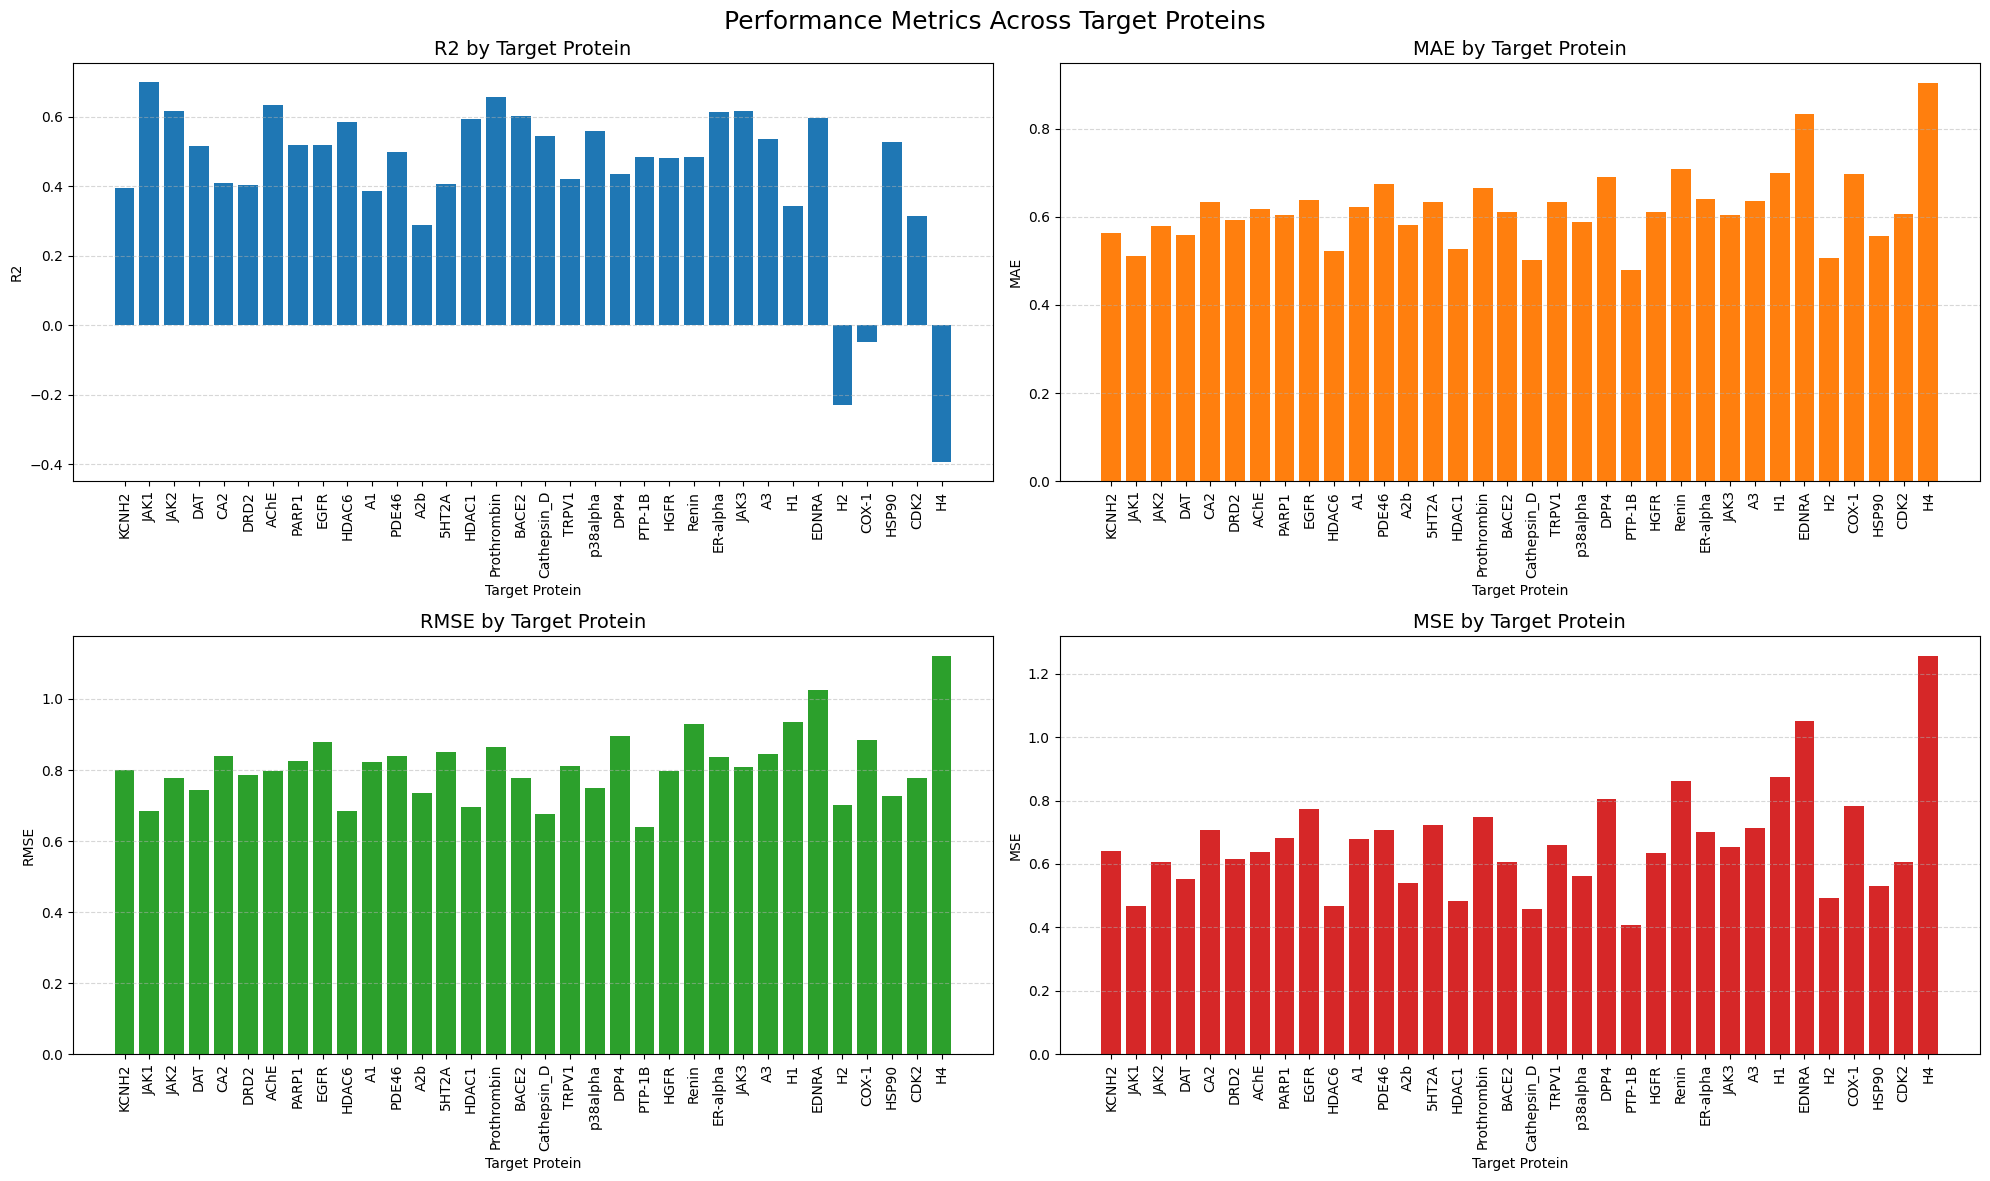

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Convert to DataFrame
df = pd.DataFrame(results).T

# Metrics to plot
metrics = ['r2', 'mae', 'rmse', 'mse', 'num']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

# Plot each metric separately
for i, metric in enumerate(metrics):
    ax = axes[i]

    ax.bar(
        df.index,
        df[metric],
        color=colors[i]
    )

    ax.set_title(f'{metric.upper()} by Target Protein', fontsize=14)
    ax.set_xlabel('Target Protein')
    ax.set_ylabel(metric.upper())

    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Overall title
fig.suptitle('Performance Metrics Across Target Proteins', fontsize=18)

plt.tight_layout()
plt.show()